In [49]:
from pathlib import Path
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os


epochs = 100
batch_size = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        # Input size is 50*200
        # Encoder
        self.enc_fc1 = nn.Linear(50 * 200, 400)
        self.enc_fc2_mu = nn.Linear(400, latent_dim)
        self.enc_fc2_logvar = nn.Linear(400, latent_dim)
        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, 400)
        self.dec_fc2 = nn.Linear(400, 50 * 200)

    def encoder(self, x):
        x = x.view(-1, 50 * 200)
        h1 = F.relu(self.enc_fc1(x))
        mu = self.enc_fc2_mu(h1)
        logvar = self.enc_fc2_logvar(h1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decoder(self, z):
        h3 = F.relu(self.dec_fc1(z))
        return torch.sigmoid(self.dec_fc2(h3)).view(-1, 50, 200)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

In [ ]:
class CaptchaDataset(Dataset):
    def __init__(self, path: str):
        self.path = Path(path)
        self.image_files = list(self.path.glob("*.png"))
        print(f"Found {len(self.image_files)} PNG images in {path}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index: int) -> torch.Tensor:
        img_path = self.image_files[index]
        image = Image.open(img_path).convert("L")  # convert to grayscale

        image = np.array(image, dtype=np.float32) / 255.0  # Normalize to [0, 1]

        # ensure the image is 50x200
        if image.shape != (50, 200):
            print(
                f"Warning: Image {img_path} has shape {image.shape}, expected (50, 200)"
            )
            # resize if necessary
            image = np.array(
                Image.fromarray((image * 255).astype(np.uint8)).resize((200, 50))
            )
            image = image.astype(np.float32) / 255.0

        # convert to tensor
        image = torch.tensor(image).unsqueeze(0)
        return image

    @property
    def shape(self) -> tuple:
        return (len(self.image_files), 1, 50, 200)

In [52]:
def interpolate_latent_space(model, z1, z2, steps=10):
    return [z1 * (1 - t) + z2 * t for t in np.linspace(0, 1, steps)]


def visualize_interpolation(model, z1, z2, steps=10, device="cpu"):
    """
    Interpolates between z1 and z2 in latent space and visualizes the decoded outputs.
    """
    model.eval()
    interpolated = interpolate_latent_space(model, z1, z2, steps)
    decoded_imgs = []
    with torch.no_grad():
        for z in interpolated:
            z = z.to(device)
            recon = model.decoder(z.unsqueeze(0))
            decoded_imgs.append(recon.cpu().squeeze().numpy())

    fig, axes = plt.subplots(1, steps, figsize=(steps * 4, 2))
    for i, img in enumerate(decoded_imgs):
        axes[i].imshow(img, cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"Step {i+1}")
    plt.tight_layout()
    plt.show()


def visualize_reconstruction(model, dataset, device="cpu", num_samples=5):
    """
    Visualize original images and their reconstructions
    """
    model.eval()

    # get random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 4, 8))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            # original image
            original = dataset[idx].to(device)
            axes[0, i].imshow(original.squeeze().cpu().numpy(), cmap="gray")
            axes[0, i].set_title("Original")
            axes[0, i].axis("off")

            # reconstructed image
            recon, _, _ = model(original.unsqueeze(0))
            axes[1, i].imshow(recon.squeeze().cpu().numpy(), cmap="gray")
            axes[1, i].set_title("Reconstructed")
            axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()


def loss_function(recon_x, x, mu, logvar):
    recon_x = recon_x.view(-1, 50 * 200)
    x = x.view(-1, 50 * 200)
    BCE = F.binary_cross_entropy(recon_x, x, reduction="sum")
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

Found 134 PNG images in ../data/captcha
Dataset shape: (134, 1, 50, 200)
Model initialized with latent dimension: 20
Model parameters: 8034840
training VAE...
Saved trained VAE to vae_captcha.pth


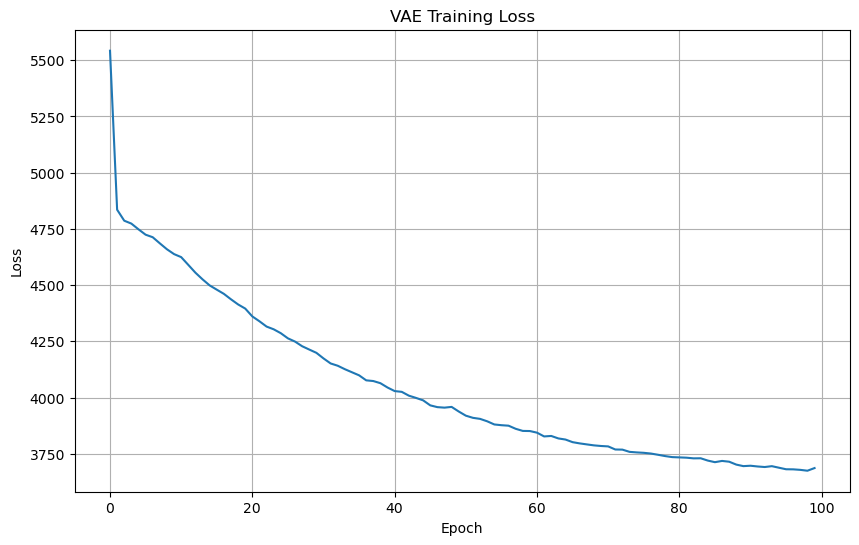

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

# Load dataset
dataset = CaptchaDataset("../data/captcha")
print(f"Dataset shape: {dataset.shape}")

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)

print(f"Model initialized with latent dimension: {latent_dim}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

# training setup
model_path = "vae_captcha.pth"

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"load {model_path}")
else:
    print("training VAE...")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    train_losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        num_batches = 0

        for batch_idx, data in enumerate(dataloader):
            data = data.to(device)

            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss = loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / len(dataset)
        train_losses.append(avg_loss)

        # print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")

    # save model
    torch.save(model.state_dict(), model_path)
    print(f"Saved trained VAE to {model_path}")

    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses)
    plt.title("VAE Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

Visualizing reconstructions...


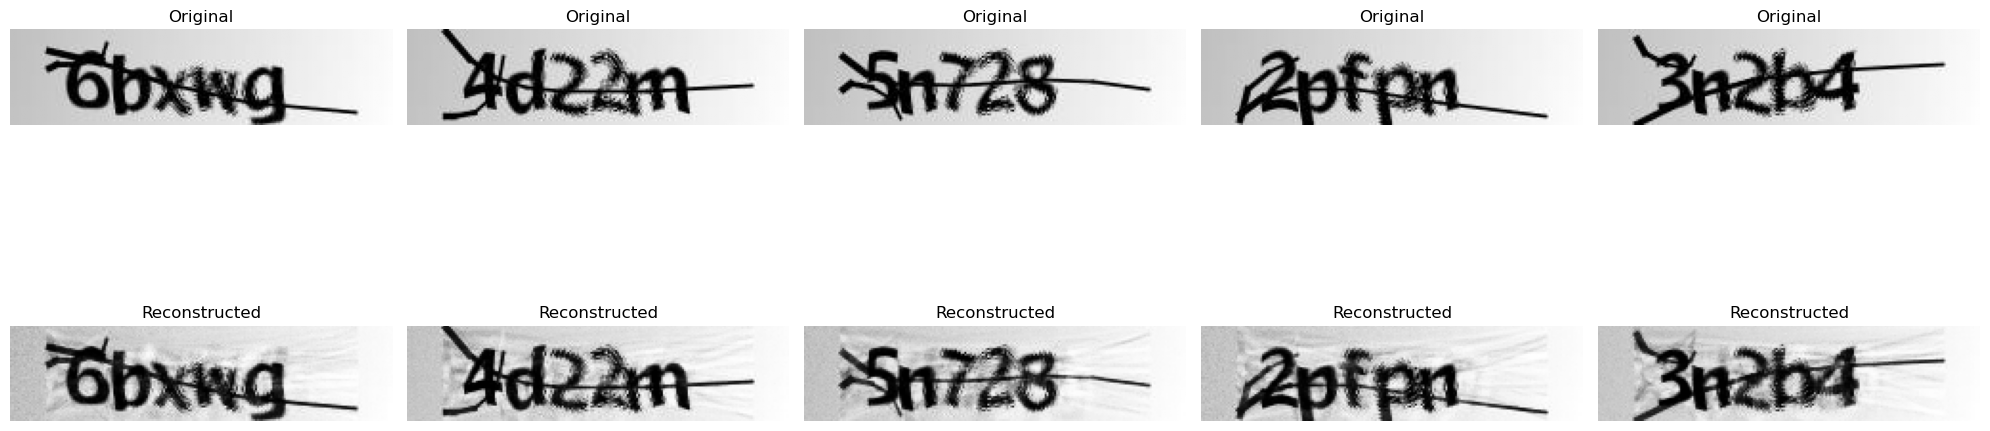

Performing latent space interpolation...


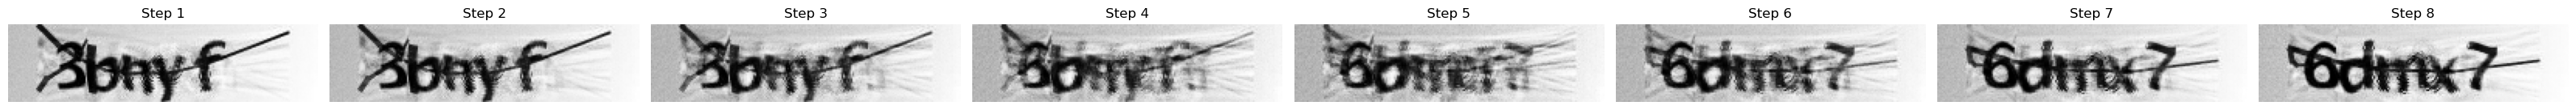

Generating random samples from latent space...


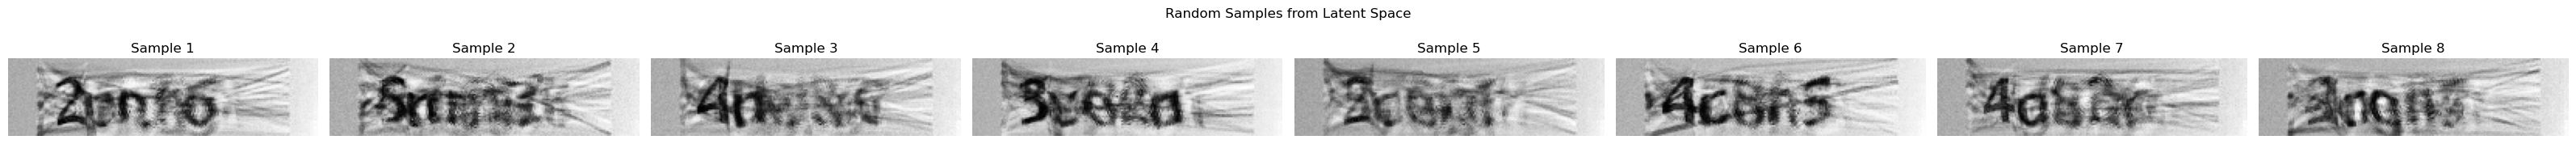

In [ ]:
model.eval()

print("Visualizing reconstructions...")
visualize_reconstruction(model, dataset, device=device, num_samples=5)


print("Performing latent space interpolation...")
idx1, idx2 = np.random.choice(len(dataset), 2, replace=False)
img1 = dataset[idx1].to(device)
img2 = dataset[idx2].to(device)

# Encode to latent space
with torch.no_grad():
    z1 = model.encoder(img1.unsqueeze(0))[0].squeeze()
    z2 = model.encoder(img2.unsqueeze(0))[0].squeeze()

visualize_interpolation(model, z1, z2, steps=8, device=device)


print("Generating random samples from latent space...")
model.eval()
num_samples = 8

with torch.no_grad():
    z = torch.randn(num_samples, latent_dim).to(device)
    samples = model.decoder(z)

fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 4, 2))
for i in range(num_samples):
    axes[i].imshow(samples[i].cpu().numpy(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Sample {i+1}")

plt.suptitle("Random Samples from Latent Space")
plt.tight_layout()
plt.show()